In [1]:
import math

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def plot_attn_mask(mask, cbar_orientation=None):
    fig, ax = plt.subplots()
    ax.set_aspect("equal")
    cax = ax.imshow(mask, cmap="viridis", interpolation="nearest")
    if cbar_orientation:
        fig.colorbar(cax, ax=ax, orientation=cbar_orientation, pad=0.1)
    ax.set_xticks(np.arange(-0.5, mask.shape[1], 1))
    ax.set_yticks(np.arange(-0.5, mask.shape[0], 1))
    ax.grid(which="major", color="k", linestyle="-", linewidth=1)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(which="both", length=0)
    plt.show()

In [3]:
Klen = 64
nsa_l = 4  # compression block size
nsa_d = 2  # sliding stride
nsa_L = 8  # selected block size
nsa_n = 4  # selected block count (including fixed activating the 1 initial block and 2 local blocks)
nsa_w = 16  # window size

# Token compression attention mask

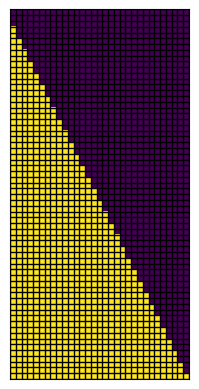

In [4]:
n_cmp_blocks = math.floor((Klen - nsa_l) / nsa_d) + 1
largest_k_index_in_cmp_block = jnp.array([i * nsa_d + nsa_l - 1 for i in range(n_cmp_blocks)])
q_index = jnp.arange(Klen)[:, jnp.newaxis]
cmp_mask = largest_k_index_in_cmp_block <= q_index
plot_attn_mask(cmp_mask)

# Token selection attention mask

## Importance score computation

Form `p_slc_mask` to compute $\mathbf{p}_t^\text{slc}$ from $\mathbf{p}_t^\text{cmp}$ as in [Equation 9](https://arxiv.org/pdf/2502.11089#page=7):
```python
p_slc = einsum("n_slc_blocks n_cmp_blocks, n_cmp_blocks -> n_slc_blocks", p_slc_mask, p_cmp)
```

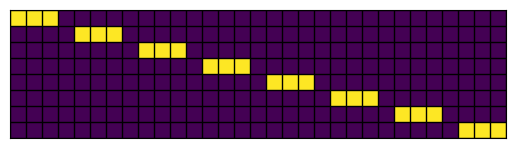

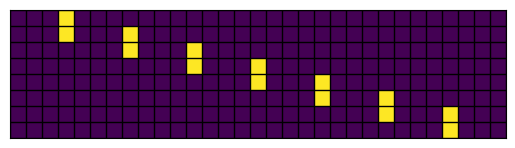

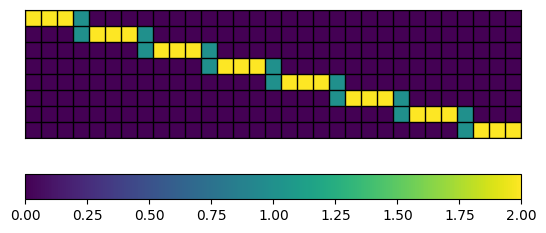

In [5]:
n_slc_blocks = Klen // nsa_L
largest_k_index_in_cmp_block = jnp.array([i * nsa_d + nsa_l - 1 for i in range(n_cmp_blocks)])
largest_k_index_in_slc_block = jnp.array([(i + 1) * nsa_L - 1 for i in range(n_slc_blocks)])
smallest_k_index_in_cmp_block = jnp.array([i * nsa_d for i in range(n_cmp_blocks)])
smallest_k_index_in_slc_block = jnp.array([i * nsa_L for i in range(n_slc_blocks)])

total_overlap_mask = jnp.logical_and(
    largest_k_index_in_cmp_block[jnp.newaxis, :] <= largest_k_index_in_slc_block[:, jnp.newaxis],
    smallest_k_index_in_cmp_block[jnp.newaxis, :] >= smallest_k_index_in_slc_block[:, jnp.newaxis],
)
plot_attn_mask(total_overlap_mask)

partial_overlap_mask = jnp.logical_or(
    jnp.logical_and(
        largest_k_index_in_cmp_block[jnp.newaxis, :] > largest_k_index_in_slc_block[:, jnp.newaxis],
        smallest_k_index_in_cmp_block[jnp.newaxis, :] < largest_k_index_in_slc_block[:, jnp.newaxis],
    ),
    jnp.logical_and(
        largest_k_index_in_cmp_block[jnp.newaxis, :] > smallest_k_index_in_slc_block[:, jnp.newaxis],
        smallest_k_index_in_cmp_block[jnp.newaxis, :] < smallest_k_index_in_slc_block[:, jnp.newaxis],
    ),
)
plot_attn_mask(partial_overlap_mask)

p_slc_mask = 2 * total_overlap_mask + partial_overlap_mask
plot_attn_mask(p_slc_mask, cbar_orientation="horizontal")

## Static component
"fixed activating the 1 initial block and 2 local blocks"

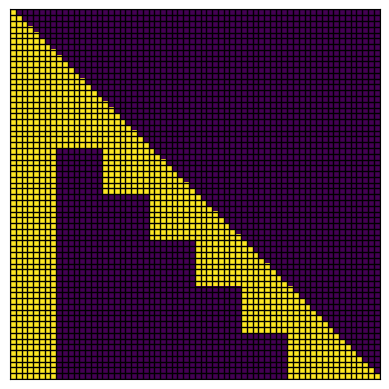

In [6]:
k_index = jnp.arange(Klen)[jnp.newaxis, :]
initial_slc_block_mask = jnp.concatenate(
    [jnp.zeros((nsa_L, Klen)), jnp.repeat(k_index < nsa_L, Klen - nsa_L, axis=0)], axis=0
)
q_index = jnp.arange(Klen)[:, jnp.newaxis]
q_slc_block_index = (q_index // nsa_L) * nsa_L
local_slc_blocks_mask = jnp.logical_and(k_index < q_slc_block_index, k_index + 1 * nsa_L >= q_slc_block_index)
chunk_mask = jnp.logical_and(k_index <= q_index, k_index >= q_slc_block_index)
static_slc_mask = jnp.logical_or(chunk_mask, jnp.logical_or(initial_slc_block_mask, local_slc_blocks_mask))
plot_attn_mask(static_slc_mask)

## Dynamic component

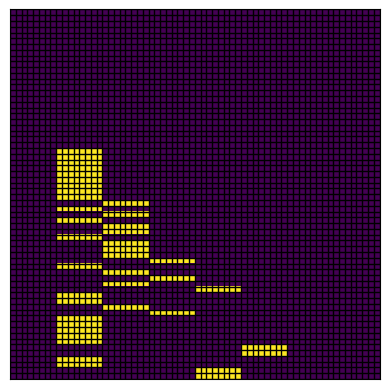

In [7]:
def get_dynamic_slc_mask(p_slc):
    block_indices_to_rank = [jnp.arange(1, t // nsa_L)[:-1] for t in range(Klen)]
    ranked_slc_block_indices = [jnp.argsort(p_slc[t][block_indices_to_rank[t]], descending=True) for t in range(Klen)]
    dynamic_slc_block_indices = [(1 + ranked_slc_block_indices[t])[: nsa_n - 3] for t in range(Klen)]
    dynamic_slc_mask = jnp.zeros((Klen, Klen))
    for t in range(Klen):
        for i in dynamic_slc_block_indices[t]:
            dynamic_slc_mask = jax.lax.dynamic_update_slice(dynamic_slc_mask, jnp.ones((1, nsa_L)), (t, i * nsa_L))
    return dynamic_slc_mask


n_slc_blocks = Klen // nsa_L
p_slc = jax.random.uniform(jax.random.key(0), (Klen, n_slc_blocks))
dynamic_slc_mask = get_dynamic_slc_mask(p_slc)
plot_attn_mask(dynamic_slc_mask)

## Combined

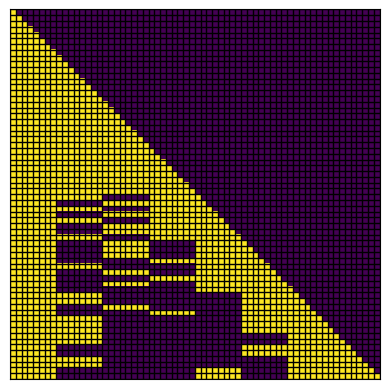

In [8]:
slc_mask = jnp.logical_or(static_slc_mask, dynamic_slc_mask)
plot_attn_mask(slc_mask)

# Sliding window attention mask

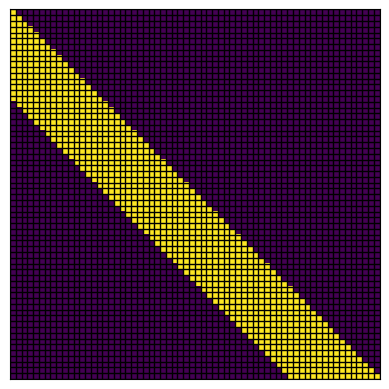

In [9]:
q_index = jnp.arange(Klen)[:, jnp.newaxis]
k_index = jnp.arange(Klen)[jnp.newaxis, :]
window_mask = jnp.logical_and(k_index <= q_index, k_index + nsa_w > q_index)
plot_attn_mask(window_mask)

# Test 1

This test using synthetic queries and keys ought to detect violations of causality during `mask(einsum("qd,kd->qk", q, k))`, but not during `jnp.einsum("qk,kd->qd", probs, v)`.

In [10]:
q = jnp.eye(Klen)  # Each row is a query (a basis vector) of dimension d_head = Klen
k = jnp.tril(jnp.ones((Klen, Klen)), -1)  # Each row is a key (a sum of basis vectors) of dimension d_head = Klen

logits = jnp.einsum("qd,kd->qk", q, k)
# logits is 1 above the diagonal and 0 elsewhere, so that applying a non-causal mask will yield a non-zero matrix

## Vanilla

In [11]:
for largest_nonzero_subdiagonal in [-1, 0, 1, 2]:
    causal_mask = jnp.tril(jnp.ones((Klen, Klen), dtype=jnp.bool_), largest_nonzero_subdiagonal)
    probs = jnp.where(causal_mask, logits, 0)
    print(
        f"largest_nonzero_subdiagonal = {largest_nonzero_subdiagonal:<3}\tnorm(masked_logits) = {jnp.linalg.norm(probs)}"
    )
# As expected, largest_nonzero_subdiagonal > 0 => norm(masked_logits) > 0 => information leakage from future tokens

largest_nonzero_subdiagonal = -1 	norm(masked_logits) = 0.0
largest_nonzero_subdiagonal = 0  	norm(masked_logits) = 0.0
largest_nonzero_subdiagonal = 1  	norm(masked_logits) = 7.937253952026367
largest_nonzero_subdiagonal = 2  	norm(masked_logits) = 11.180339813232422


## Token compression

In [12]:
# Simulate token compression by averaging adjacent keys across the sequence-length dimension
k_blocks = jnp.stack([k[i * nsa_d : i * nsa_d + nsa_l, :] for i in range(n_cmp_blocks)])
k_cmp = jnp.mean(k_blocks, axis=1)  # Each row is a compressed key of dimension d_head = Klen

logits_cmp = jnp.einsum("qd,kd->qk", q, k_cmp)
probs_cmp = jnp.where(cmp_mask, logits_cmp, 0)
print(jnp.linalg.norm(probs_cmp))

0.0


## Token selection

In [13]:
probs_slc = jnp.where(slc_mask, logits, 0)
print(jnp.linalg.norm(probs_slc))

0.0


## Window attention

In [14]:
probs_win = jnp.where(window_mask, logits, 0)
print(jnp.linalg.norm(probs_win))

0.0
